In [1]:
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import py_dss_interface
from opendssdirect import dss

In [2]:
(pd.read_csv("../data/curves/13BUS_curve.csv", index_col='timestamp').columns)

Index(['load-671', 'load-634a', 'load-634b', 'load-634c', 'load-645',
       'load-646', 'load-692', 'load-675a', 'load-675b', 'load-675c',
       'load-611', 'load-652', 'load-670a', 'load-670b', 'load-670c'],
      dtype='object')

In [3]:
file_path = "D:\\UFC\\2-MESTRADO\\1-semestre\\ESTUDOS ESPECIAIS EM ENGENHARIA ELETRICA II (THP7244)\\lucas\\trabalho-final\\projeto\\THP7244-final-project\\data\\13Bus\\IEEE13Nodeckt.dss"


In [4]:
dss.Command("Clear")
dss.Command(f"redirect '{file_path}'")
dss.Command('Solve')

In [5]:
loads = dss.Loads.AllNames()
loads

['671',
 '634a',
 '634b',
 '634c',
 '645',
 '646',
 '692',
 '675a',
 '675b',
 '675c',
 '611',
 '652',
 '670a',
 '670b',
 '670c']

In [6]:
config_elements = {}

i = int(4)
for load in loads:
    if i < 10:
        config_elements[f'Load.{load}'] = {
            'file': '../data/14885589/90-id_261.csv',
            'type': 'load',
            'column': 'load power (kW)',
            'time-step': 300,        # 5 minutos
            'date': f'2018-01-0{i}'     # Data de interesse
        }
    else:
        config_elements[f'Load.{load}'] = {
            'file': '../data/14885589/90-id_261.csv',
            'type': 'load',
            'column': 'load power (kW)',
            'time-step': 300,        # 5 minutos
            'date': f'2018-01-{i}'     # Data de interesse
        }
    i += 1

In [7]:
config_elements

{'Load.671': {'file': '../data/14885589/90-id_261.csv',
  'type': 'load',
  'column': 'load power (kW)',
  'time-step': 300,
  'date': '2018-01-04'},
 'Load.634a': {'file': '../data/14885589/90-id_261.csv',
  'type': 'load',
  'column': 'load power (kW)',
  'time-step': 300,
  'date': '2018-01-05'},
 'Load.634b': {'file': '../data/14885589/90-id_261.csv',
  'type': 'load',
  'column': 'load power (kW)',
  'time-step': 300,
  'date': '2018-01-06'},
 'Load.634c': {'file': '../data/14885589/90-id_261.csv',
  'type': 'load',
  'column': 'load power (kW)',
  'time-step': 300,
  'date': '2018-01-07'},
 'Load.645': {'file': '../data/14885589/90-id_261.csv',
  'type': 'load',
  'column': 'load power (kW)',
  'time-step': 300,
  'date': '2018-01-08'},
 'Load.646': {'file': '../data/14885589/90-id_261.csv',
  'type': 'load',
  'column': 'load power (kW)',
  'time-step': 300,
  'date': '2018-01-09'},
 'Load.692': {'file': '../data/14885589/90-id_261.csv',
  'type': 'load',
  'column': 'load power

In [8]:
def build_normalized_dataframe_24h(config_dict):
    """
    Gera um DataFrame unificado em p.u. garantindo 24 horas completas (00:00 a 23:59).
    """
    series_list = []
    metadata = {}
    
    # --- PASSO CRUCIAL: Criar o "Canvas" de 24 horas ---
    # Data fictícia para padronização
    dummy_date_str = '2000-01-01'
    dummy_date = pd.Timestamp(dummy_date_str)
    
    # Cria um índice completo de 00:00 até 23:55 (passo de 5 min = 300s)
    # 24h * 12 intervalos/h = 288 pontos
    full_day_index = pd.date_range(start=f"{dummy_date_str} 00:00:00", 
                                   periods=288, 
                                   freq='300s')
    
    print(f"Processando {len(config_dict)} elementos...")
    
    for name, cfg in config_dict.items():
        try:
            # 1. Leitura Inteligente (Detecta coluna de tempo)
            header_preview = pd.read_csv(cfg['file'], nrows=0)
            time_col_name = header_preview.columns[0]
            target_col_name = cfg['column']
            
            # Lê CSV
            df_raw = pd.read_csv(cfg['file'], usecols=[time_col_name, target_col_name])
            df_raw.rename(columns={time_col_name: 'timestamp'}, inplace=True)
            df_raw['timestamp'] = pd.to_datetime(df_raw['timestamp'], unit='s')
            
            # 2. Filtragem pela Data Alvo
            target_date_str = cfg['date']
            target_date = pd.to_datetime(target_date_str).date()
            
            mask = df_raw['timestamp'].dt.date == target_date
            df_day = df_raw.loc[mask].copy()
            
            # Se não houver dados naquele dia, criamos uma série vazia
            if df_day.empty:
                print(f"AVISO: {name} -> Sem dados em {target_date_str}. Preenchendo com 0.")
                series_data = pd.Series(dtype=float)
            else:
                df_day.set_index('timestamp', inplace=True)
                series_data = df_day[target_col_name]

            # 3. Mapear para o Dia Fictício (2000-01-01)
            # Isso move os dados de "2017-12-31 14:00" para "2000-01-01 14:00"
            if not series_data.empty:
                series_data.index = series_data.index.map(
                    lambda t: t.replace(year=dummy_date.year, month=dummy_date.month, day=dummy_date.day)
                )

            # 4. Reindexar para garantir as 24 horas completas
            # O método .reindex() pega os dados existentes e os coloca no nosso full_day_index.
            # Onde não houver dados (madrugada ou fim da noite), preenche com 0.
            # O 'tolerance' ajuda a pegar dados próximos se o timestamp não for exato (ex: 00:00:01)
            series_24h = series_data.reindex(full_day_index, method='nearest', tolerance=pd.Timedelta('1min'), fill_value=0)
            
            # 5. Normalização (p.u.)
            peak_val = series_24h.abs().max()
            
            if peak_val == 0:
                series_pu = series_24h # Já é tudo zero
                peak_val = 1.0 
            else:
                series_pu = series_24h / peak_val
            
            series_pu.name = name
            series_list.append(series_pu)
            
            metadata[name] = {
                'source_date': target_date_str,
                'peak_kw': peak_val,
                'type': cfg['type']
            }
            
            print(f"-> {name}: OK. Pico: {peak_val:.3f} kW")
            
        except Exception as e:
            print(f"ERRO CRÍTICO em {name}: {e}")
            
    # 6. Consolidação
    if series_list:
        df_final = pd.concat(series_list, axis=1)
        return df_final, metadata
    else:
        return pd.DataFrame(), {}

Processando 15 elementos...
-> Load.671: OK. Pico: 9.094 kW
-> Load.634a: OK. Pico: 9.366 kW
-> Load.634b: OK. Pico: 10.341 kW
-> Load.634c: OK. Pico: 9.022 kW
-> Load.645: OK. Pico: 9.683 kW
-> Load.646: OK. Pico: 6.966 kW
-> Load.692: OK. Pico: 11.069 kW
-> Load.675a: OK. Pico: 10.743 kW
-> Load.675b: OK. Pico: 12.144 kW
-> Load.675c: OK. Pico: 13.738 kW
-> Load.611: OK. Pico: 13.418 kW
-> Load.652: OK. Pico: 13.669 kW
-> Load.670a: OK. Pico: 13.202 kW
-> Load.670b: OK. Pico: 12.553 kW
-> Load.670c: OK. Pico: 13.617 kW

--- Metadados ---
{
  "Load.671": {
    "source_date": "2018-01-04",
    "peak_kw": 9.093820458167,
    "type": "load"
  },
  "Load.634a": {
    "source_date": "2018-01-05",
    "peak_kw": 9.3660653936332,
    "type": "load"
  },
  "Load.634b": {
    "source_date": "2018-01-06",
    "peak_kw": 10.341273592213,
    "type": "load"
  },
  "Load.634c": {
    "source_date": "2018-01-07",
    "peak_kw": 9.021687557306002,
    "type": "load"
  },
  "Load.645": {
    "source_

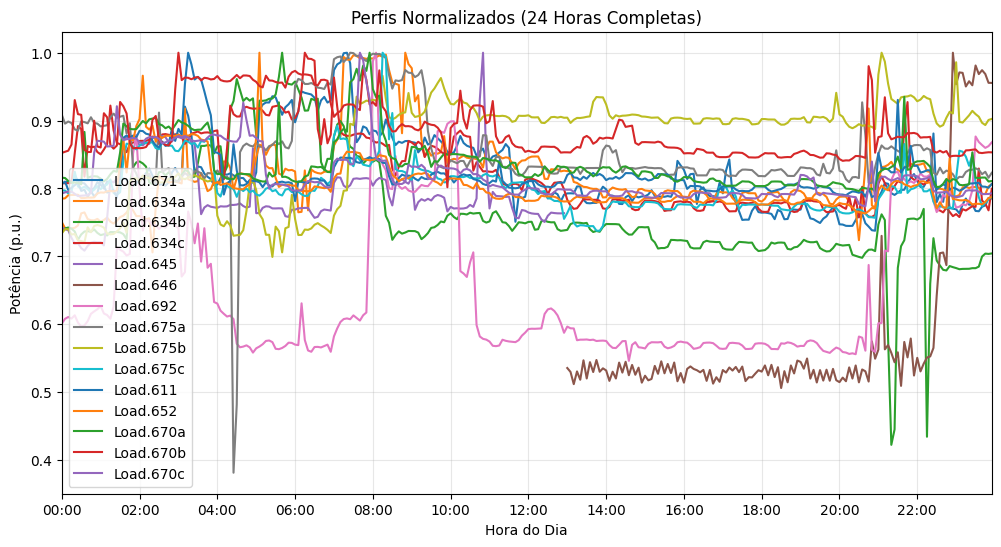


--- Início e Fim do DataFrame ---
                     Load.671  Load.634a  Load.634b  Load.634c  Load.645  Load.646  Load.692  Load.675a  Load.675b  Load.675c  Load.611  Load.652  Load.670a  Load.670b  Load.670c
2000-01-01 00:00:00  0.807253   0.750314   0.736149   0.807966  0.742574       NaN  0.600800   0.908642   0.733714   0.797055  0.806446  0.784840   0.815829   0.852366   0.792460
2000-01-01 00:05:00  0.808851   0.741444   0.740960   0.807459  0.739738       NaN  0.607763   0.895434   0.739927   0.796825  0.810092  0.785417   0.815331   0.854029   0.794165
2000-01-01 23:50:00  0.785828   0.802798   0.703433   0.767665       NaN  0.955643  0.862340   0.815730   0.900898   0.784214  0.801046  0.785911   0.810233   0.853295   0.791812
2000-01-01 23:55:00  0.785072   0.806493   0.704143   0.799497       NaN  0.955502  0.867886   0.823056   0.902437   0.787346  0.806394  0.786996   0.810853   0.853168   0.792820


In [9]:
# --- EXECUTANDO ---
df_pu, meta_info = build_normalized_dataframe_24h(config_elements)

print("\n--- Metadados ---")
print(json.dumps(meta_info, indent=2, default=str))

# --- PLOTAGEM CORRIGIDA (Eixo X formatado) ---
if not df_pu.empty:
    fig, ax = plt.subplots(figsize=(12, 6))
    
    # Plotar cada coluna
    for col in df_pu.columns:
        ax.plot(df_pu.index, df_pu[col], label=col)
    
    # Formatação do Eixo X para mostrar apenas HORAS
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
    ax.xaxis.set_major_locator(mdates.HourLocator(interval=2)) # Marca a cada 2 horas
    
    # Limites exatos (00:00 a 23:55)
    ax.set_xlim(df_pu.index[0], df_pu.index[-1])
    
    plt.title("Perfis Normalizados (24 Horas Completas)")
    plt.xlabel("Hora do Dia")
    plt.ylabel("Potência (p.u.)")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()
    
    # Mostrar início e fim do dataframe para provar que começa às 00:00
    print("\n--- Início e Fim do DataFrame ---")
    print(df_pu.iloc[[0, 1, -2, -1]].to_string())

In [11]:
nomes = [f'Load.{i}' for i in loads]
nomes

['Load.671',
 'Load.634a',
 'Load.634b',
 'Load.634c',
 'Load.645',
 'Load.646',
 'Load.692',
 'Load.675a',
 'Load.675b',
 'Load.675c',
 'Load.611',
 'Load.652',
 'Load.670a',
 'Load.670b',
 'Load.670c']

In [13]:
df_pu.columns = nomes
df_pu.columns

Index(['Load.671', 'Load.634a', 'Load.634b', 'Load.634c', 'Load.645',
       'Load.646', 'Load.692', 'Load.675a', 'Load.675b', 'Load.675c',
       'Load.611', 'Load.652', 'Load.670a', 'Load.670b', 'Load.670c'],
      dtype='object')

In [14]:
df_pu.to_csv('../data/curves/13BUS_curve.csv', index_label='timestamp')